<a href="https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/L3_Colab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 3.3 IO-Link data collection using JSON interface


## 3.1 Python programming for data collection from IO-Link master

The entire schematic of the data communication using JSON interface using REST API for the IO-Link vibraton device from the IO-Link master is illustrated in Figure 15. As the power meter data collection, your computers (laptop and Raspberry Pi) are on the router network. The IO-Link master is also on the same router network with a static IP address. The ethernet cable (RJ45) is used for connection between the router and the IO-Link master. Note that the IO-Link vibration sensor is connected to the **port 1** of the master. In this case using REST API, each of your computer is not a master but client. The IO-Link master is a server. The data communication sequence to read data from the IO-Link master is summarized as follows.

1.  The computer (Raspberry Pi or laptop) requests data using REST API's post method to the IO-Link master
2.  The IO-Link master read the IO-Link sensor data by the IO-Link protocol
3.  The IO-Link master sends back the received data from the IO-Link sensor to the computer as the JSON format.
4.  The computer receives the JSON data and parse it.

To do this, we will use Python and 'requests' and 'json' packages which are the basic packages in Python. Moreover, refer to details of JSON interface of the IFM IO-Link master [here](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/IFM_JSON_Integration_for_IO-Link.pdf?raw=true). The IO-Link vibration sensor (VVB001) manual for interface is also available [here](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/IFM_VVB001_IO-Link_Interface_Description.pdf?raw=true). **Please note that this lab manual skips all details to extract data for your convenience. If you perform data collection from other IoT devices, the first thing you have to do is to read the manual and figure out data communication protocols and take appropriate action.**

<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/lab3_fig15.png?raw=true" width="90%">

_Figure 15 Schematic of communication for IO-Link data collection using JSON interface_

**The IP address of the gateway at Lab3**.
<br/>
Offline class : 192.168.1.102
<br/>
<font color=”green”> Online class </font> : 10.165.67.146


### Task 3.1

Capture the results of checking network connection using ping test from both Raspberry Pi and laptop to the IO-Link master for REST API as Figure 13 ([Lab3.2](https://githubtocolab.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/L3_Colab2.ipynb)) and attach it to the report.

- Please note that the IP address of the IO-Link master will be different from the example.


---
Purdue ECN blocked PING
---


---
Purdue ECN blocked PING
---


If ping test works, you are ready to request data. Before we request data to the IO-Link master, let's see what data is available from the sensor. The selected available data is shown in Table 4. These information is also available on the manual [here](https://github.com/Eunseob/purdue_me597/blob/main/lab/lab3/IFM_VVB001_IO-Link_Interface_Description.pdf?raw=true) on page 9. Other than data from Table 4, tens of more data are available. In this lab, we will collect the selected data only. The refresh rate of the sensor is approximately 200 msec in default setting.

**Note that to take an appropriate value with unit, a multiplier in the Range column of Table 4 must be applied after receiving data. For example, after multiplying 0.0001 to v-Rms value, the measured data has unit of m/s.**

_Table 4 Selected process data from VVB001 sensor_

<table width="100%">
<thead>
  <tr>
    <th>Process data input</th>
    <th>Description</th>
    <th>Record Type</th>
    <th>Range</th>
    <th>Unit</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td>v-Rms</td>
    <td>Speed effective value</td>
    <td rowspan="5">IntegerT (16 bit)</td>
    <td>(0 to 495)*0.0001</td>
    <td>m/s</td>
  </tr>
  <tr>
    <td>a-Peak</td>
    <td>Acceleration peak value</td>
    <td>(0 to 4903)*0.1</td>
    <td>m/s2</td>
  </tr>
  <tr>
    <td>a_Rms</td>
    <td>Acceleration effective value</td>
    <td>(0 to 4903)*0.1</td>
    <td>m/s2</td>
  </tr>
  <tr>
    <td>Temperature</td>
    <td>Current temperature</td>
    <td>(-300 to 800)*0.1</td>
    <td>°C</td>
  </tr>
  <tr>
    <td>Crest</td>
    <td>Acceleration crest factor</td>
    <td>(10 to 500)*0.1</td>
    <td>-</td>
  </tr>
</tbody>
</table>


---

**<img src="https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/img/icon_Python.png?raw=tru" width="20">Python - Python 3 ([lab3_sample2.py](https://github.com/purduelamm/purdue_me597_iiot/blob/main/lab/lab3/lab3_sample2.py?raw=true))**

```
import requests
import json
import datetime

# define the IO-Link master IP
URL = "http://192.168.1.102/" # For online student with Cisco VPN : 10.165.67.146

# define JSON body for post method
# for the details, see the JSON interface manual
# note that the sensor is connected to port 1
BODY = {
        "code":"request",
        "cid":-1,
        "adr":"/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
        "data":{"index":40,"subindex":0}    
}

now = datetime.datetime.now()

# this requests data to the IO-Link master
# using POST method of REST API with BODY information
# req object will be response from the IO-Link master
req = requests.post(url = URL, json=BODY)

data_json = req.json() # this is json format data of req

# because the the JSON data itself is in unformatted,
# dumps method of JSON module below helps us to see the data in JSON format
data_json_formatted = json.dumps(data_json, indent=2)

print(now, ': Data structure from the IO-Link master\n',data_json_formatted)

# parsing JSON:
# as you can see the above print,
# 'value' is accesible in 'data' of the JSON data
value = data_json['data']['value']

# the raw measured value looks like 0000FC000002FF000000FF0000F6FF000026FF03
# the length of the value is 40
# this is byte array in 16-bit integer format
print('raw measured value is', value)


# Always, the returned value type from JSON is string
# below is converting the value to v-Rms
# description of v_rms variable is that
# first, select first four elements from value
# second, convert them into 16-bit integer
# third, multiply 0.0001 to take the correct unit (m/s) and data
# finally, rounding up and the data type is float
v_rms = round(int(value[0:4], 16) * 0.0001)

print('v_Rms =', v_rms ,'m/s')

### indexing information is that
# a_Peak data = value[8:12]
# a_Rms data = value[16:20]
# Temperature data = value[24:28]
# Crest data = value[32:36]

```

---

The sample code 2 (lab3_sample2.py) is given as above. This code is to print out v_Rms. Go through the code and run it. Based on the given code, perform the Tasks below.


### Task 3.2

Modify the sample code 2 on both laptop and Raspberry Pi to print out all data (v_Rms, a_Peak, a_Rms, Temperature, and Crest) as Table 4.

- Print the values with units in Table 4


---
<img src="https://github.com/rd908213/ME-597-IIoT/blob/main/lab/lab3/img/L3_Task3.2_1.png?raw=true" width="100%">
---


---
<img src="https://github.com/rd908213/ME-597-IIoT/blob/main/lab/lab3/img/L3_Task3.2_2.png?raw=true" width="100%">
---


### Task 3.3

1. Perform the same as Task 2.3; Modify sample code 2 to collect IO-Link data for at least 1 minute and save data as a CSV file.

- You can use one computer either laptop or Raspberry Pi.
- Set the sampling period 1 second.
- Data (header) should include time or datetime, v_Rms, a_Peak, a_Rms, Temperature, Crest as Table 5.
- As a practice, plot data and calculate time-domain features.

_Table 5 Example data of output CSV file for Task 3.3_

<table width="100%">
<thead>
  <tr>
    <th>Time [sec]</th>
    <th>v_Rms [m/s]</th>
    <th>a_Peak [m/s2]</th>
    <th>a_Rms [m/s2]</th>
    <th>Temperature [C]</th>
    <th>Crest [-]</th>
  </tr>
</thead>
<tbody>
  <tr>
    <td colspan="6" align="center">...</td>
  </tr>
  <tr>
    <td>10.254</td>
    <td>0.001</td>
    <td>1.24</td>
    <td>0.48</td>
    <td>24.1</td>
    <td>2.58</td>
  </tr>
  <tr>
    <td>10.461</td>
    <td>0.002</td>
    <td>1.34</td>
    <td>0.51</td>
    <td>23.9</td>
    <td>2.63</td>
  </tr>
  <tr>
    <td colspan="6" align="center">...</td>
  </tr>
</tbody>
</table>


In [12]:
### Place your entire code for Task 3.3 Here
# If you want, you can add more code block below to load csv file and plot it.
import requests
import json
import datetime
import time
import pandas as pd


class IOLinkMaster:
    def __init__(self, url):
        self.url = url
        self.body = {
            "code": "request",
            "cid": -1,
            "adr": "/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
            "data": {"index": 40, "subindex": 0},
        }

    def get_data(self) -> tuple:
        req = requests.post(url=self.url, json=self.body)
        data_json = req.json()
        value = data_json["data"]["value"]
        v_rms = round(int(value[0:4], 16) * 0.0001)
        a_peak = round(int(value[8:12], 16) * 0.1)
        a_rms = round(int(value[16:20], 16) * 0.1)
        temperature = round(int(value[24:28], 16) * 0.1)
        crest = round(int(value[32:36], 16) * 0.1)
        return v_rms, a_peak, a_rms, temperature, crest


URL = "http://10.165.67.146/"
INPUTS = [
    "v_Rms [m/s]",
    "a_Peak [m/s^2]",
    "a_Rms [m/s^2]",
    "Temperature [C]",
    "Crest [-]",
]
df = pd.DataFrame(columns=["Time [s]"] + INPUTS)

iolink_master = IOLinkMaster(URL)
start_time = time.time()
while time.time() - start_time < 60:
    v_rms, a_peak, a_rms, temperature, crest = iolink_master.get_data()
    current_time = time.time() - start_time
    df.loc[len(df)] = {
        "Time [s]": current_time,
        "v_Rms [m/s]": v_rms,
        "a_Peak [m/s^2]": a_peak,
        "a_Rms [m/s^2]": a_rms,
        "Temperature [C]": temperature,
        "Crest [-]": crest,
    }

    print(
        f"Time: {current_time:.2f} s, v_Rms: {v_rms} m/s, a_Peak: {a_peak} m/s^2, a_Rms: {a_rms} m/s^2, Temperature: {temperature} C, Crest: {crest}"
    )
    time.sleep(1)


df.to_csv(
    f"iolink_data{datetime.datetime.now().strftime('%Y%m%d_%H%M%S')}.csv",
    index=False,
)

Time: 1.79 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 2.89 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 5.92 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 8.70 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 9.79 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 12.82 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 5
Time: 13.92 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 15.01 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 16.10 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 17.19 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 18.28 s, v_Rms: 0 m/s, a_Peak: 0 m/s^2, a_Rms: 0 m/s^2, Temperature: 28 C, Crest: 4
Time: 21.31 s, 

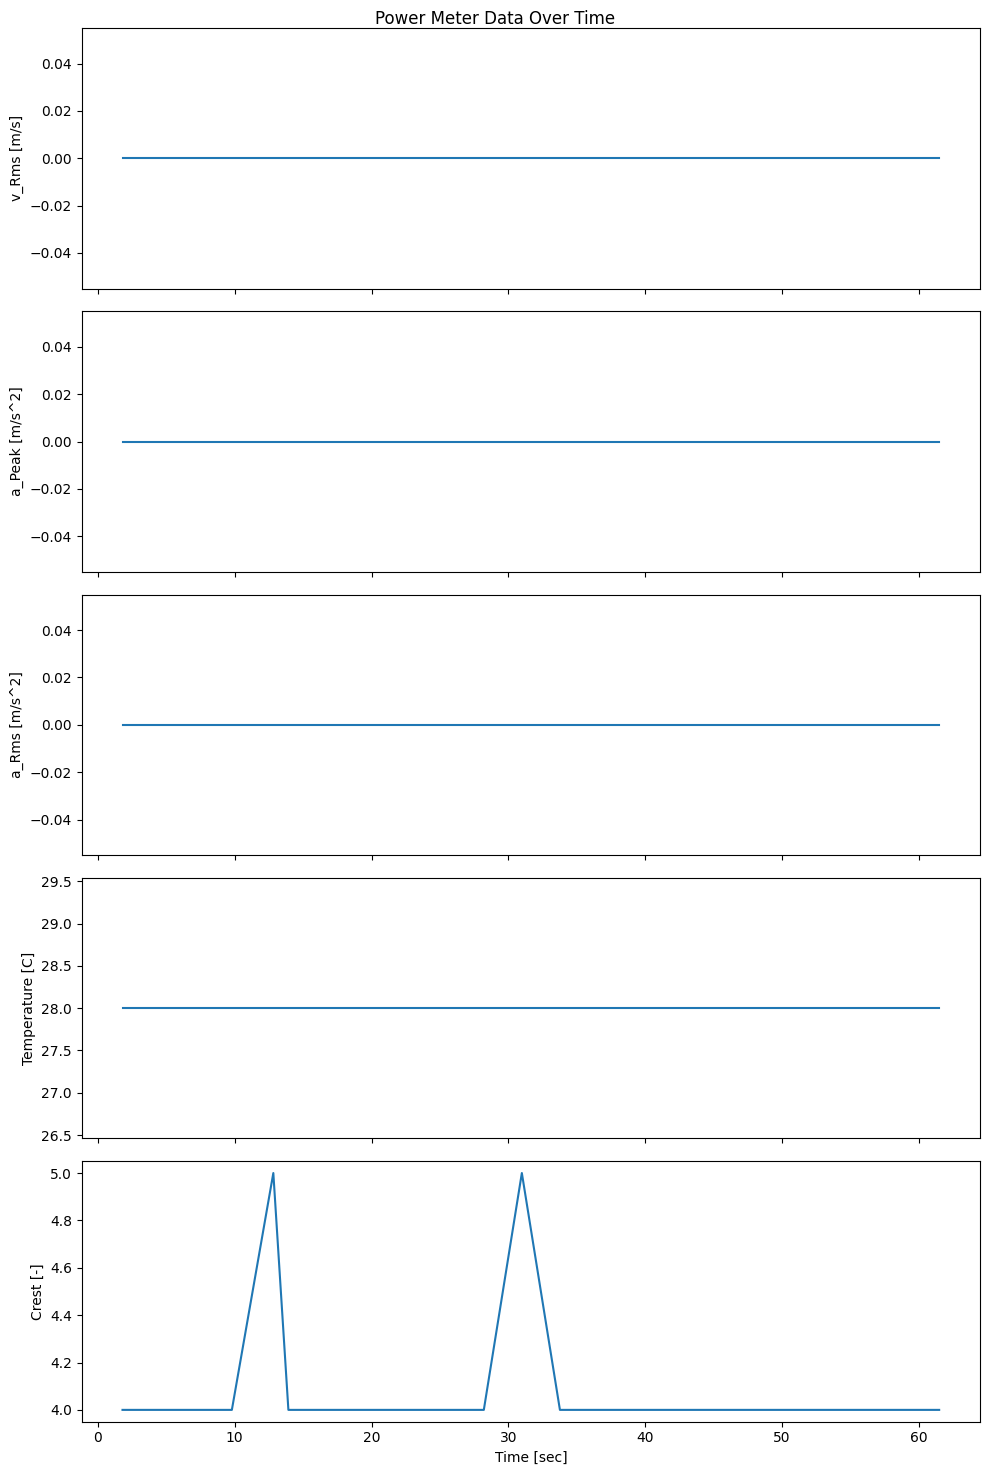

In [13]:
# Plot data
import matplotlib.pyplot as plt

fig, axs = plt.subplots(len(INPUTS), 1, figsize=(10, 15), sharex=True)
for i, col in enumerate(INPUTS):
    axs[i].plot(df["Time [s]"], df[col], label=col)
    axs[i].set_ylabel(col)
axs[-1].set_xlabel("Time [sec]")
fig.suptitle("Power Meter Data Over Time")
plt.tight_layout()
plt.show()

In [17]:
# Calculate time-domain features
import numpy as np

td_df = pd.DataFrame(
    columns=[
        "Mean",
        "Standard Deviation",
        "Root Mean Square",
        "Peak",
        "Skewness",
        "Kurtosis",
        "Crest Factor",
    ],
    index=INPUTS,
)
for input in INPUTS:
    data = df[input]
    td_df.loc[input] = [
        np.mean(data),
        np.std(data),
        np.sqrt(np.mean(data**2)),
        np.max(data),
        pd.Series(data).skew(),
        pd.Series(data).kurtosis(),
        np.max(np.abs(data)) / np.sqrt(np.mean(data**2)),
    ]

print(td_df)

                     Mean Standard Deviation Root Mean Square Peak Skewness  \
v_Rms [m/s]           0.0                0.0              0.0    0      0.0   
a_Peak [m/s^2]        0.0                0.0              0.0    0      0.0   
a_Rms [m/s^2]         0.0                0.0              0.0    0      0.0   
Temperature [C]      28.0                0.0             28.0   28      0.0   
Crest [-]        4.068966           0.253395         4.076848    5  3.59052   

                  Kurtosis Crest Factor  
v_Rms [m/s]            0.0          NaN  
a_Peak [m/s^2]         0.0          NaN  
a_Rms [m/s^2]          0.0          NaN  
Temperature [C]        0.0          1.0  
Crest [-]        11.695473     1.226438  


C:\Users\rd908\AppData\Local\Temp\ipykernel_14288\4237988881.py:25: RuntimeWarning: invalid value encountered in scalar divide
  np.max(np.abs(data)) / np.sqrt(np.mean(data**2)),
C:\Users\rd908\AppData\Local\Temp\ipykernel_14288\4237988881.py:25: RuntimeWarning: invalid value encountered in scalar divide
  np.max(np.abs(data)) / np.sqrt(np.mean(data**2)),
C:\Users\rd908\AppData\Local\Temp\ipykernel_14288\4237988881.py:25: RuntimeWarning: invalid value encountered in scalar divide
  np.max(np.abs(data)) / np.sqrt(np.mean(data**2)),


## 3.2 Data collection from multiple sensors in a single program

In this lab so far, we collected data from each sensor in a program. In this section, we try to collect data from both sensors at the same time in a single program.

Perform the Tasks below.


### Task 3.4

By using the sample code 1 and 2, program a Python code as instructed below.

- Make infinitely printing out all sensor data at the same time in a 'while' loop.
- Use 'try' and 'except' to halt your program when pressing Ctrl+c.
- Capture your console window or terminal when your program is running and attach it below.
- You can use either laptop or Raspberry Pi to run this code.


---
Place your screenshot for Task 3.4 here.
---


In [ ]:
### place your code for Task 3.4
from pymodbus.client.sync import ModbusTcpClient
from pymodbus.constants import Endian
from pymodbus.payload import BinaryPayloadDecoder
import requests
import datetime
import asyncio

URL = "http://10.165.67.146/"
BODY = {
    "code": "request",
    "cid": -1,
    "adr": "/iolinkmaster/port[1]/iolinkdevice/iolreadacyclic",
    "data": {"index": 40, "subindex": 0},
}
HOST = "10.165.67.146"
PORT = 502


class PowerMeterRegister:
    def __init__(self, name: str, address: int) -> float:
        self.name = name
        self.address = address

    async def read_register(self, client: ModbusTcpClient):
        read = client.read_holding_registers(self.address, count=2, unit=1)

        if read.isError():
            client.close()
            raise RuntimeError(f"Modbus read error: {read}")

        reg = read.registers

        decoder = BinaryPayloadDecoder.fromRegisters(
            reg, byteorder=Endian.Big, wordorder=Endian.Big
        )

        value = decoder.decode_32bit_float()
        return value


registers = [
    PowerMeterRegister("Frequency [Hz]", 1536),
    PowerMeterRegister("Voltage 1 [V]", 1538),
    PowerMeterRegister("Current 1 [A]", 1550),
    PowerMeterRegister("Power Factor [-]", 1582),
    PowerMeterRegister("True Power [W]", 1564),
]


async def read_modbus_data(client):
    if not client.connect():
        raise RuntimeError(f"Connect failed: {HOST}:{PORT}")

    now = datetime.datetime.now()

    for reg in registers:
        value = await reg.read_register(client)
        print(f"{now}: {reg.name} is {value}")


async def read_iolink_data():
    now = datetime.datetime.now()
    req = requests.post(url=URL, json=BODY)
    data_json = req.json()
    value = data_json["data"]["value"]
    v_rms = round(int(value[0:4], 16) * 0.0001)
    a_peak = round(int(value[8:12], 16) * 0.1)
    a_rms = round(int(value[16:20], 16) * 0.1)
    temperature = round(int(value[24:28], 16) * 0.1)
    crest = round(int(value[32:36], 16) * 0.1)
    print(f"{now}: v_Rms [m/s] is {v_rms}")
    print(f"{now}: a_Peak [m/s^2] is {a_peak}")
    print(f"{now}: a_Rms [m/s^2] is {a_rms}")
    print(f"{now}: Temperature [C] is {temperature}")
    print(f"{now}: Crest [-] is {crest}")


async def main():
    await asyncio.gather(read_modbus_data(client), read_iolink_data())


while True:
    with ModbusTcpClient(HOST, port=PORT) as client:
        # Run both tasks concurrently so as to not block one another
        asyncio.run(main())

---
<img src="https://github.com/rd908213/ME-597-IIoT/blob/main/lab/lab3/img/L3_Task3.4.png?raw=true" width="100%">
---


### Task 3.5

Let's think more about IoT sensors and data collection in the sense of the programmer. The answers are open-ended. Answer the questions below.


#### 1) If you want to collect data from muliple sensors which have different sampling periods, how can you implement your program?


---

I would use write asynchronous functions that sample each sensor independently so that threads dedicated to one sensor are not blocked by the other.

---


#### 2) How can you make your program robust/stable even if suddenly unwanted network connection failure happens?


---
To make the program more robust/stable if suddenly unwanted network connection failure happens, I would include try/except statements to attempt to reconnect. If a reconnection is impossible (for example, if a sensor physically becomes unplugged), I would print an error code. If the program is used to sample more than one sensor, I would either:
  a) Include an in-memory store of sensor status and stop sampling a sensor with a connection issue.
  b) Print a connection failure message each time the sensor is supposed to be sampled.
  
---


#### 3) What can you do with the electrical power and vibration data? Can they be used for an operational condition or health monitoring?


---

With electrical power, I would be able to measure the operational condition of an electrical device (is it turned on, are there any faults). If it is a battery, I would also be able to measure its power output to check for battery health or charge.

With vibration data, I could check for operational condition and health of rotating machinery. For example, in a fan turbine I could check for unnecessary vibration to assess if bearings need to be replaced.

---


## Lab3 Summary and Deliverables

Answer the following questions for your achievements


### Q1. Please summarize Lab3.

---

Lab 3 covered how to connect to devices using the MODBUS protocol, and how to connect to devices using the IOLink interface and query it using RESTAPI HTTP queries. The use case was measuring the power output and vibration data of a vacuum pump.

In this specific lab, we connected to a power meter using modbus and found the following sensor readings:

1. Frequency
2. Voltage
3. Current
4. Power Factor
5. True Power

We found the following sensor readings from a vibration sensor connected to the pump:

1. Velocity
2. Peak Acceleration
3. Acceleration
4. Temperature
5. Crest

Using these sensor readings we were able to take useful measurements that could be used to analyze the life, health or status of a vacuum pump.

---


### Q2. What skills did you have to develop to accomplish this project?

---

To accomplish this project, I needed to develop my networking skills in order to communicate with the various sensors and devices for this project. I also continue to improve my python skills as shown by my brief examples of object oriented programming.

---


### Q3. What aspects of this project were the most beneficial for your learning?

---

The aspects of the project that were most beneficial for my learning were being able to connect the theory described in the prelab (communication protocols, how sensors are used) and apply them to a real-world scenario.

---


### Q4. What challenges did you encounter in completing the project?

---

I encountered an issue where even when connected to the purdue VPN, I was unable to ping the router connected to the devices. This was a difficult problem to diagnose since it could be an issue with

1. My own network
2. The VPN connection
3. The routing set up on my own computer
4. Purdue's network
5. The device itself

---


### Q5. How did you overcome the challenges or remedy the problems encountered?

---

To remedy this challenge, I consulted the TA Yuseop Sim and asked him to investigate on his end why PING was not working. At the same time, I changed my VPN settings and verified that it was correctly configured to work with the purdue VPN network. In the end, the TA found out that the issue was that Purude ECN blocks PING, so I was unable to verify the connection this way. I was able to complete the rest of the lab since methods other than PING are allowed on the network.

---


<br></br>

Get back to [Lab Index Page](https://colab.research.google.com/github/purduelamm/purdue_me597_iiot/blob/main/index.ipynb)
